# Collecting Data

In [119]:
import pandas as pd
player_df = pd.read_csv("D:\\Python-Assigment\\source code\\results.csv")
transfer_df = pd.read_csv("D:\\Python-Assigment\\source code\\Transfer_values.csv")


#merge 2 df on 
result_df = pd.merge(transfer_df,player_df,how="left", on=["Player","Team"])
result_df.replace("N/a",pd.NA,inplace=True)
# Show all rows
print(result_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 80 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Player                     299 non-null    object 
 1   Team                       299 non-null    object 
 2   Played Time                299 non-null    float64
 3   Estimated Value            299 non-null    object 
 4   Nation                     299 non-null    object 
 5   Pos                        299 non-null    object 
 6   Age                        299 non-null    float64
 7   Standard_MP                299 non-null    int64  
 8   Standard_Starts            299 non-null    int64  
 9   Standard_Min               299 non-null    float64
 10  Standard_Gls               299 non-null    int64  
 11  Standard_Ast               299 non-null    int64  
 12  Standard_CrdY              299 non-null    int64  
 13  Standard_CrdR              299 non-null    int64  

In [120]:
result_df.describe()

,Played Time,Age,Standard_MP,Standard_Starts,Standard_Min,Standard_Gls,Standard_Ast,Standard_CrdY,Standard_CrdR,Standard_xG,...,Possession_Dis,Possession_Rec,Possession_PrgR,Misc_Fls,Misc_Fld,Misc_Off,Misc_Crs,Misc_Recov,Misc_Won,Misc_Lost
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,...,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,1957.622074,27.054114,26.816054,22.224080,1957.622074,2.909699,2.153846,4.053512,0.123746,2.884281,...,18.488294,777.973244,70.628763,21.538462,21.090301,3.357860,34.408027,82.652174,25.816054,25.411371
std,614.442980,3.878346,5.712603,7.277341,614.442980,4.129840,2.537585,2.560112,0.359069,3.574817,...,16.079992,361.586557,72.046867,13.729934,14.933922,4.613487,41.439218,41.484040,23.150723,19.289946
min,903.000000,18.590000,12.000000,7.000000,903.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,189.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,1416.000000,24.180000,23.000000,16.000000,1416.000000,0.000000,0.000000,2.000000,0.000000,0.600000,...,5.000000,514.500000,8.000000,11.000000,10.000000,0.000000,3.000000,50.000000,9.000000,12.000000
50%,1960.000000,26.920000,28.000000,23.000000,1960.000000,1.000000,1.000000,4.000000,0.000000,1.400000,...,16.000000,718.000000,52.000000,20.000000,18.000000,2.000000,14.000000,76.000000,19.000000,21.000000
75%,2448.500000,29.330000,31.000000,28.000000,2448.500000,4.000000,3.000000,6.000000,0.000000,3.850000,...,27.500000,937.500000,106.500000,28.000000,30.000000,4.000000,53.000000,109.000000,36.000000,34.000000
max,3060.000000,40.030000,34.000000,34.000000,3060.000000,28.000000,18.000000,12.000000,2.000000,23.900000,...,88.000000,2063.000000,425.000000,65.000000,99.000000,27.000000,191.000000,197.000000,127.000000,117.000000


# Preprocessing Data

In [121]:

# List of columns to convert to numeric
cols_to_convert = ['Shooting_Dist', 'Passing_Long_Cmp%', 'Possession_Succ%', 
                   'Possession_Tkld%', 'Misc_Won%','Shooting_SoT%', 'Shooting_G/Sh']

# Convert only those columns to numeric
result_df[cols_to_convert] = result_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')


# Function to convert currency in '€12.6M' format to a number
def convert_to_numeric(value):
    if isinstance(value, str):
        # Remove the currency symbol and any spaces
        value = value.replace('€', '').strip()
        
        # Check for 'M' (million) and convert accordingly
        if 'M' in value:
            return float(value.replace('M', '').strip()) * 1_000_000
        # Check for 'K' (thousand) and convert accordingly
        elif 'K' in value:
            return float(value.replace('K', '').strip()) * 1_000
        # If there is no 'M' or 'K', assume the number is already in a proper format
        else:
            return float(value)
    return value

# Apply the function to the specific columns
result_df['Estimated Value'] = result_df['Estimated Value'].apply(convert_to_numeric)

result_df = result_df[result_df["Player"] != "Mohamed Salah"]
result_df = result_df.drop(
    ['Player', 'Team', 'Nation', 'Pos',
     'Goalkeeping_GA90', 'Goalkeeping_Save%',
     'Goalkeeping_CS%', 'Goalkeeping_Penalty_Save%','Standard_PrgC', 'Standard_PrgP'],
    axis=1,
    errors='ignore'
)

result_df = result_df.fillna(0)
result_df
object_col_count = result_df.select_dtypes(include='object').shape[1]
print(f"Number of object columns: {object_col_count}")
object_columns = result_df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_columns)
numeric_col_count = result_df.select_dtypes(include='number').shape[1]
print(f"Number of numeric columns: {numeric_col_count}")
numeric_columns = result_df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", numeric_columns)
result_df


Number of object columns: 0
Object columns: []
Number of numeric columns: 70
Numeric columns: ['Played Time', 'Estimated Value', 'Age', 'Standard_MP', 'Standard_Starts', 'Standard_Min', 'Standard_Gls', 'Standard_Ast', 'Standard_CrdY', 'Standard_CrdR', 'Standard_xG', 'Standard_xAG', 'Standard_PrgR', 'Standard_Gls/90', 'Standard_Ast/90', 'Standard_xG/90', 'Standard_xAG/90', 'Shooting_SoT%', 'Shooting_SoT/90', 'Shooting_G/Sh', 'Shooting_Dist', 'Passing_Cmp', 'Passing_Total_Cmp%', 'Passing_TotDist', 'Passing_Short_Cmp%', 'Passing_Medium_Cmp%', 'Passing_Long_Cmp%', 'Passing_KP', 'Passing_1/3', 'Passing_PPA', 'Passing_CrsPA', 'Passing_PrgP', 'GCA_SCA', 'GCA_SCA90', 'GCA_GCA', 'GCA_GCA90', 'Defense_Tkl', 'Defense_TklW', 'Defense_Att', 'Defense_Lost', 'Defense_Blocks', 'Defense_Sh', 'Defense_Pass', 'Defense_Int', 'Possession_Touches', 'Possession_Def Pen', 'Possession_Def 3rd', 'Possession_Mid 3rd', 'Possession_Att 3rd', 'Possession_Att Pen', 'Possession_Att', 'Possession_Succ%', 'Possession_T

,Played Time,Estimated Value,Age,Standard_MP,Standard_Starts,Standard_Min,Standard_Gls,Standard_Ast,Standard_CrdY,Standard_CrdR,...,Possession_Rec,Possession_PrgR,Misc_Fls,Misc_Fld,Misc_Off,Misc_Crs,Misc_Recov,Misc_Won,Misc_Lost,Misc_Won%
0,2340.0,18700000.0,26.96,26,26,2340.0,0,0,2,0,...,628,0,1,4,0,0,19,5,0,100.0
1,2794.0,29700000.0,27.42,32,31,2794.0,2,2,1,0,...,1135,139,22,24,4,64,155,22,29,43.1
2,2425.0,5800000.0,32.33,30,29,2425.0,3,1,5,1,...,705,91,46,5,10,23,139,29,43,40.3
3,1248.0,15100000.0,28.22,20,15,1248.0,2,2,4,0,...,286,79,12,5,9,14,23,5,9,35.7
4,1409.0,1500000.0,34.00,22,17,1409.0,0,0,6,0,...,333,31,15,11,0,30,43,12,13,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,1467.0,15800000.0,24.84,29,15,1467.0,1,1,4,0,...,692,76,15,9,4,69,40,5,9,35.7
295,1210.0,30000000.0,28.67,24,15,1210.0,2,0,7,0,...,657,3,22,18,0,2,71,4,7,36.4
296,955.0,11200000.0,31.89,15,11,955.0,0,1,2,0,...,258,34,12,6,0,19,50,3,11,21.4
297,1967.0,11000000.0,34.52,30,22,1967.0,0,5,1,0,...,1330,81,14,21,0,57,104,13,11,54.2


# Data Visualization



 Top 20 features with highest absolute correlation to the target variable:
Age --> Correlation: 0.4926
GCA_SCA --> Correlation: 0.4849
Possession_Att Pen --> Correlation: 0.4830
Standard_xG --> Correlation: 0.4685
GCA_GCA --> Correlation: 0.4684
Possession_Att 3rd --> Correlation: 0.4558
Passing_KP --> Correlation: 0.4363
Standard_Gls --> Correlation: 0.4338
Possession_1/3 --> Correlation: 0.4215
Passing_PPA --> Correlation: 0.4181
Standard_xG/90 --> Correlation: 0.4158
Standard_xAG --> Correlation: 0.4143
GCA_SCA90 --> Correlation: 0.4137
Shooting_SoT/90 --> Correlation: 0.4064
GCA_GCA90 --> Correlation: 0.3987
Possession_PrgC --> Correlation: 0.3974
Passing_PrgP --> Correlation: 0.3928
Standard_Ast --> Correlation: 0.3914
Standard_Gls/90 --> Correlation: 0.3901
Possession_Dis --> Correlation: 0.3860


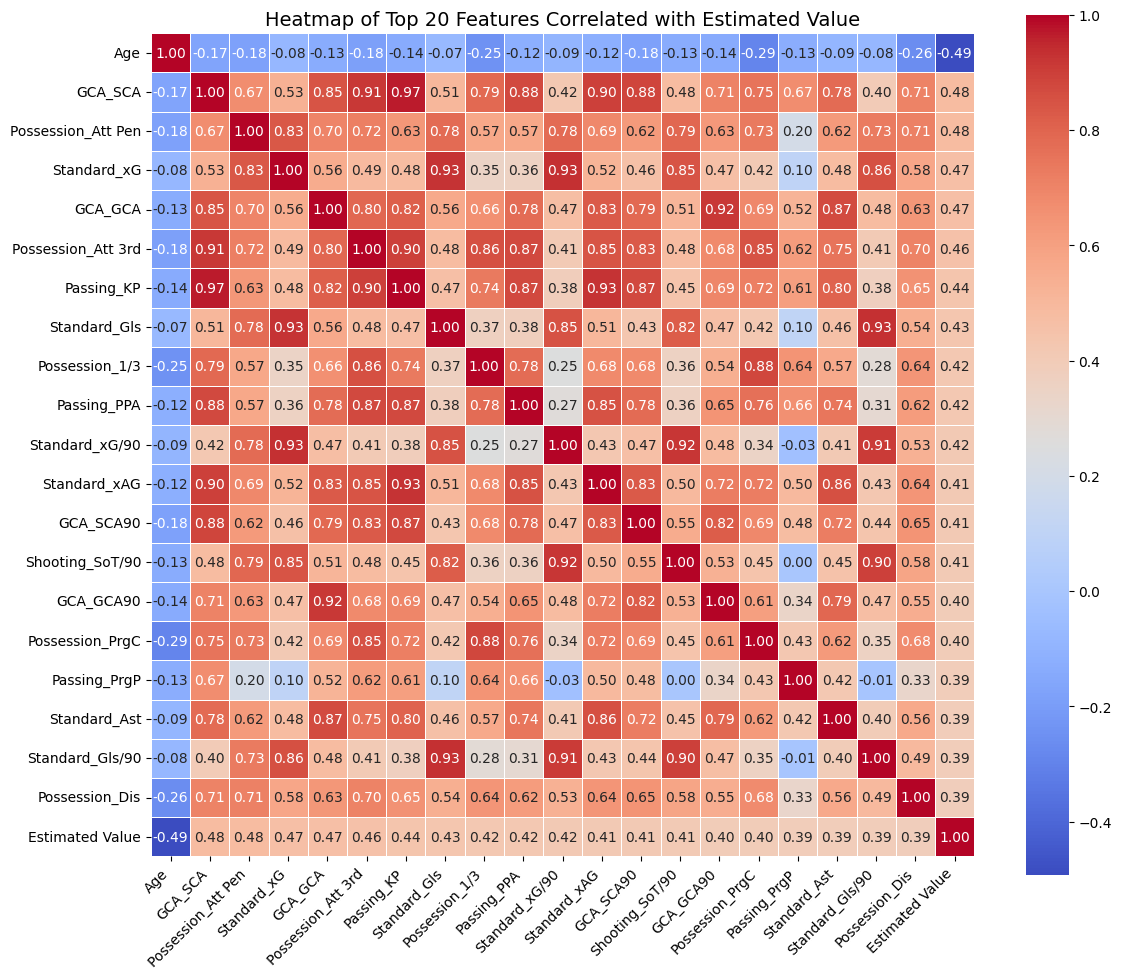

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the 20 highest absolute correlation in Estimated Value column

X = result_df.drop(columns=['Estimated Value'])  # Dropping the target column to create the feature matrix
y = result_df['Estimated Value']  # Defining the target variable

# Calculate the correlation with the target variable (y)
target_corr = X.corrwith(y).abs().sort_values(ascending=False).head(20)

# Print top 20 features most correlated with the target variable
print("\n Top 20 features with highest absolute correlation to the target variable:")
for feature, corr_val in target_corr.items():
    print(f"{feature} --> Correlation: {corr_val:.4f}")

target_corr_df = target_corr.reset_index()
target_corr_df.columns = ['Feature', 'Absolute Correlation']
# Convert top correlated feature names into a list
top_features = target_corr.index.tolist()

# Select the top 20 features and the target variable from the original dataframe
top_corr_features = result_df[top_features + ['Estimated Value']]

# Compute the correlation matrix
corr_matrix = top_corr_features.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

# Set plot title
plt.title("Heatmap of Top 20 Features Correlated with Estimated Value", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Model Building


🔹 Training Linear Regression...
Validation R²: 0.2958
Linear Regression - Test MSE: 407251953306491.6250, MAE: 15472350.5731, R²: 0.4459

🔹 Training Ridge Regression...
Validation R²: 0.3463
Ridge Regression - Test MSE: 413195026382597.6250, MAE: 15930198.2009, R²: 0.4378

🔹 Training Lasso Regression...
Validation R²: 0.2958
Lasso Regression - Test MSE: 407253663085828.7500, MAE: 15472396.9143, R²: 0.4459

🔹 Training Random Forest...


d:\Python-Assigment\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.883e+16, tolerance: 1.357e+13
  model = cd_fast.enet_coordinate_descent(


Validation R²: 0.2691
Random Forest - Test MSE: 412449413200000.0000, MAE: 14860266.6667, R²: 0.4388

🔹 Training XGBoost...
Validation R²: 0.2306
XGBoost - Test MSE: 473903318745565.3125, MAE: 15534683.5500, R²: 0.3552


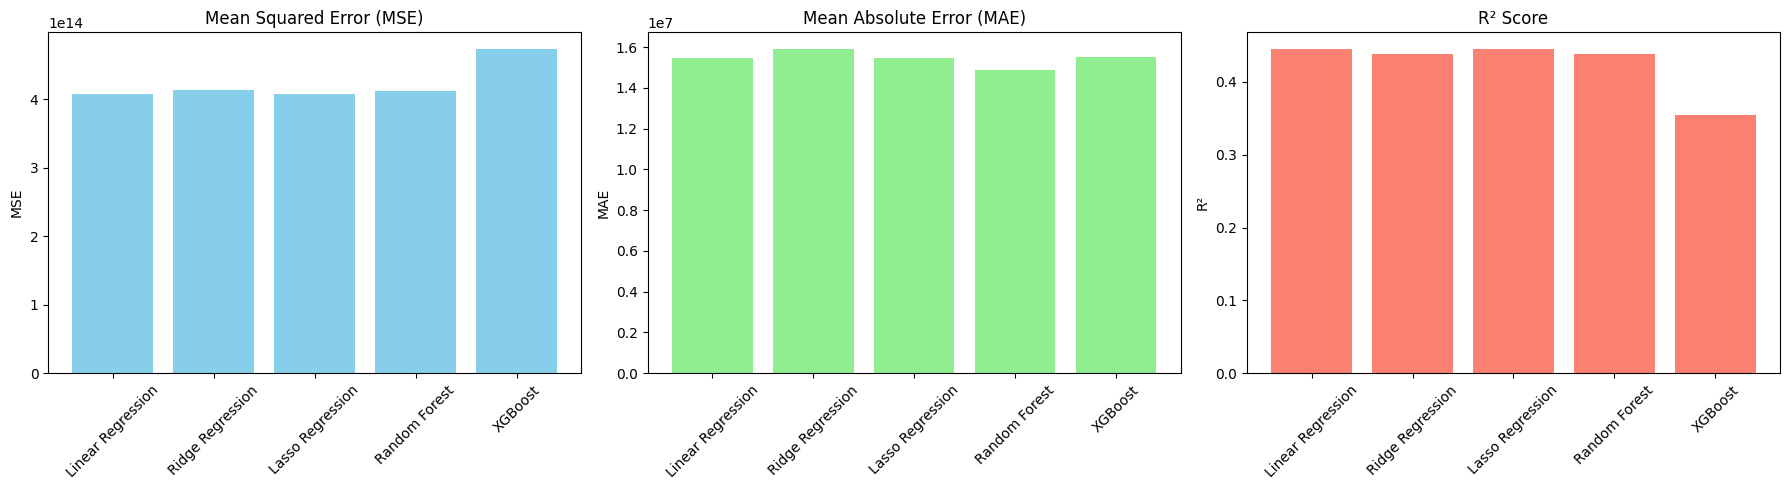

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

# === Define X and y ===
X = result_df[top_features]
y = result_df['Estimated Value']

# First split: Train (80%) vs Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=0)

# Second split: Temp (20%) into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

# === Define models ===
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(random_state=0),
    "XGBoost": xgb.XGBRegressor(random_state=0, verbosity=0)
}

# === Initialize metrics for plotting ===
metrics = {
    'Model': [],
    'MSE': [],
    'MAE': [],
    'R²': []
}

# === Train, Evaluate, Save models ===
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)  # Train on the correct training data

    # Predict on test set
    y_pred = model.predict(X_test)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Evaluation on test set
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Evaluation on validation set (just print)
    val_r2 = r2_score(y_val, y_val_pred)
    print(f"Validation R²: {val_r2:.4f}")

    # Store metrics for plotting (only test set)
    metrics['Model'].append(name)
    metrics['MSE'].append(mse)
    metrics['MAE'].append(mae)
    metrics['R²'].append(r2)

    # Print the model scores
    print(f"{name} - Test MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# === Plotting comparison of models ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot MSE
axes[0].bar(metrics['Model'], metrics['MSE'], color='skyblue')
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
axes[1].bar(metrics['Model'], metrics['MAE'], color='lightgreen')
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot R²
axes[2].bar(metrics['Model'], metrics['R²'], color='salmon')
axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Data split into training and testing sets.
Linear Regression training completed.

Model Performance:
Training R²: 0.6034
Test R²: 0.6093

Cross-validation MSE on training set: -0.4637643522315796

Training Metrics:
  MSE : 396539195983729.6875
  MAE : 13125385.8330
  R²  : 0.6034

Test Metrics:
  MSE : 328716983341225.0000
  MAE : 13554540.1071
  R²  : 0.6093


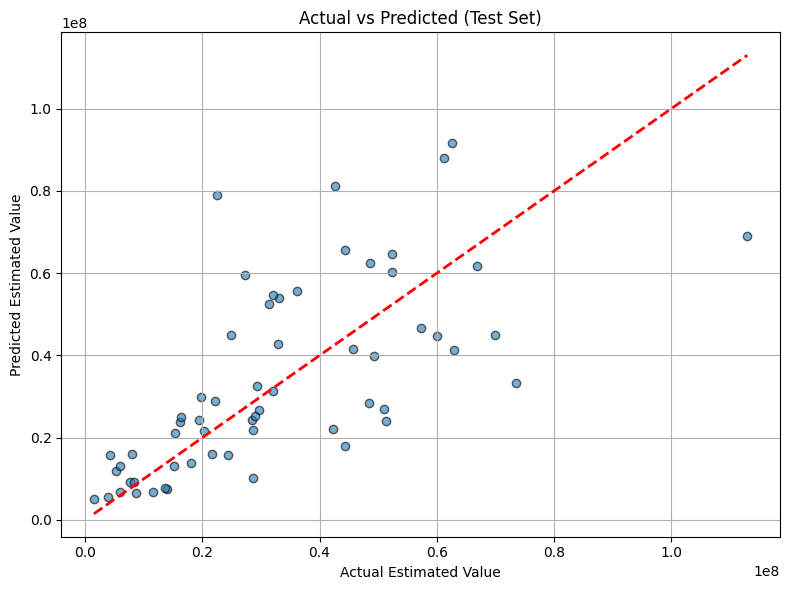

In [124]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# === Step 1: Filter dataset ===
required_columns = top_features + ['Estimated Value']
dataset = result_df[required_columns]

# === Step 2: Handle missing values ===
dataset = dataset.dropna(subset=['Estimated Value'])
dataset[top_features] = dataset[top_features].fillna(dataset[top_features].median())

# === Step 3: Define X and y (log-transform y) ===
X = dataset[top_features]
y = np.log1p(dataset['Estimated Value'])

# === Step 4: Split data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)
print("Data split into training and testing sets.")

# === Step 5: Standardize features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === Step 6: Train linear regression model ===
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression training completed.")

# === Step 7: Evaluate R² ===
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print("\nModel Performance:")
print(f"Training R²: {train_score:.4f}")
print(f"Test R²: {test_score:.4f}")

# === Step 8: Cross-validation MSE ===
cv_mse = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print("\nCross-validation MSE on training set:", cv_mse.mean())

# === Step 9: Make predictions (log scale) ===
y_train_pred_log = model.predict(X_train_scaled)
y_test_pred_log = model.predict(X_test_scaled)

# === Step 10: Convert predictions back to original scale ===
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

# === Step 11: Define metric reporting function ===
def print_mixed_metrics(y_true_log, y_pred_log, y_true_orig, y_pred_orig, dataset_name):
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    r2 = r2_score(y_true_log, y_pred_log)
    print(f"\n{dataset_name} Metrics:")
    print(f"  MSE : {mse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")

# === Step 12: Print metrics ===
print_mixed_metrics(y_train, y_train_pred_log, y_train_actual, y_train_pred, "Training")
print_mixed_metrics(y_test, y_test_pred_log, y_test_actual, y_test_pred, "Test")

# === Step 13: Plot Actual vs Predicted (Test Set) ===
plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_test_pred, alpha=0.6, edgecolor='k')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linestyle='--', linewidth=2)
plt.xlabel('Actual Estimated Value')
plt.ylabel('Predicted Estimated Value')
plt.title('Actual vs Predicted (Test Set)')
plt.grid(True)
plt.tight_layout()
plt.show()
